# Vectorized Long-Short Backtest

A local vectorized backtest replaces the Zipline runtime while preserving the long-short signal workflow.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=118)
_, scored, diagnostics = fit_signal_model(panel)
backtest = long_short_backtest(scored)
summary = pd.Series({
    'periods': len(backtest),
    'mean_return': backtest['strategy_return'].mean(),
    'volatility': backtest['strategy_return'].std(),
    'sharpe_like': backtest['strategy_return'].mean() / backtest['strategy_return'].std() * (252 / 5) ** 0.5,
    'ending_equity': backtest['equity_curve'].iloc[-1],
})
backtest.to_parquet(OUTPUT / 'long_short_backtest.parquet')
summary.to_csv(OUTPUT / 'long_short_backtest_summary.csv')
summary.to_frame('value')

,value
periods,172.0000
mean_return,0.0009
volatility,0.0136
sharpe_like,0.4632
ending_equity,1.1464


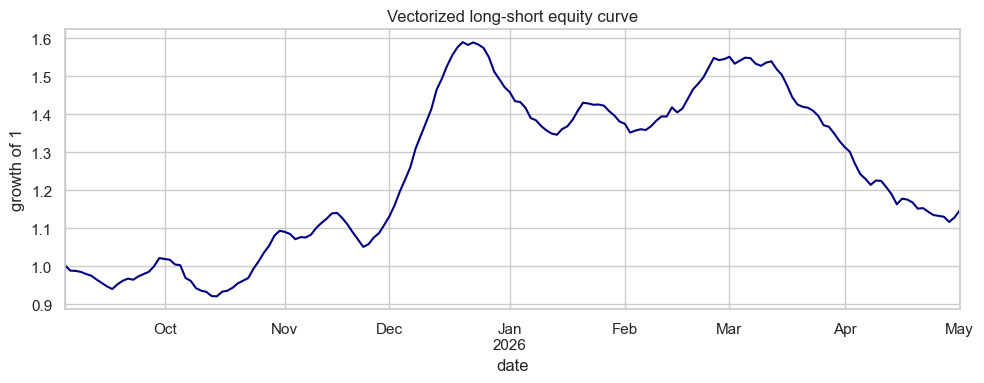

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
backtest['equity_curve'].plot(ax=ax, color='navy')
ax.set(title='Vectorized long-short equity curve', ylabel='growth of 1')
plt.tight_layout()